In [8]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [9]:
N= 100
B= 100

In [10]:
true_intercept = 20        # baseline likeness score with everything at zero
true_b_dilation = 2.0      # true effect of pupil dilation on likeness
true_b_gaze = 1.5          # true effect of gaze duration on likeness
true_b_heart = 0.5         # true effect of heart rate (our true weakest effect)
true_b_frontal = 4.0       # true effect of frontal lobe activation (our true strongest effect)
noise_sd = 5               # how much random noise we add
rho = 0.5                  # correlation between pupil dilation and gaze duration

beta_true = np.array([true_b_dilation, true_b_gaze, true_b_heart, true_b_frontal])
names = ["Pupil dilation", "Gaze duration", "Heart rate", "Frontal lobe"]

def generate_data (seed, n=N):
 rng = np.random.default_rng(seed)
 dilation = rng.normal(size=n)
 gaze = rho * dilation + np.sqrt(1 - rho**2) * rng.normal(size=n)
 heart = rng.normal(size=n)
 frontal = rng.normal(size=n)
 X = np.column_stack((dilation, gaze, heart, frontal))
 y = (true_intercept + X @ beta_true + rng.normal(scale=noise_sd, size=n))
 return X, y


In [11]:
X_test, y_test = generate_data(seed=101, n=2000) #this is our test set, which we will use to evaluate the performance of our models

sample_coefficients =  []
sample_mse = []

for i in range (1, B+1):
    X, y = generate_data(seed=i)
    model = LinearRegression().fit(X, y)
    sample_coefficients.append(model.coef_)
    sample_mse.append(mean_squared_error(y_test, model.predict(X_test)))

sample_coefficients = np.array(sample_coefficients)
sample_mse = np.array(sample_mse)

print("True beta:          ", beta_true)
print("Mean of estimates:  ", sample_coefficients.mean(axis=0).round(3))
print("SD of estimates:    ", sample_coefficients.std(axis=0).round(3))
print("Min of estimates:   ", sample_coefficients.min(axis=0).round(3))
print("Max of estimates:   ", sample_coefficients.max(axis=0).round(3))
print("Test MSE: mean", sample_mse.mean().round(2),
      "| min", sample_mse.min().round(2), "| max", sample_mse.max().round(2))
sample_rmse = np.sqrt(sample_mse)   # RMSE = back in "likeness points"
print("Test RMSE: mean", sample_rmse.mean().round(2),
      "| min", sample_rmse.min().round(2), "| max", sample_rmse.max().round(2))

True beta:           [2.  1.5 0.5 4. ]
Mean of estimates:   [1.989 1.446 0.579 3.946]
SD of estimates:     [0.636 0.543 0.515 0.548]
Min of estimates:    [ 0.071 -0.359 -0.795  2.413]
Max of estimates:    [3.311 2.561 1.719 5.555]
Test MSE: mean 26.31 | min 24.88 | max 31.26
Test RMSE: mean 5.13 | min 4.99 | max 5.59


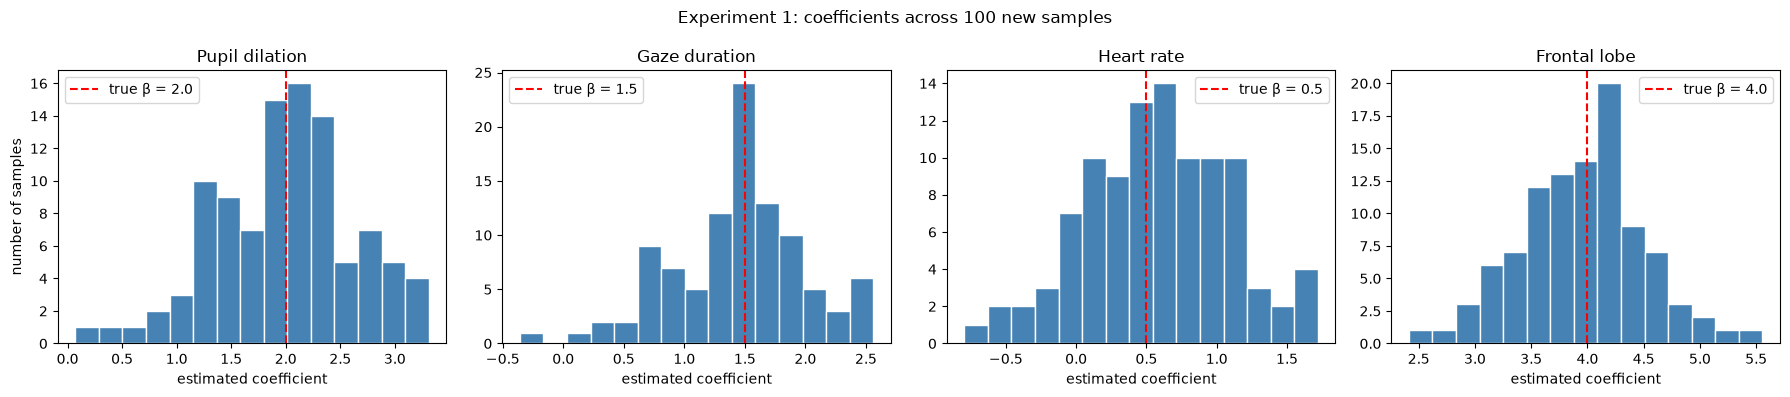

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))   # 4 plots side by side

for j, ax in enumerate(axes):                      # j = 0, 1, 2, 3 → one feature per plot
    ax.hist(sample_coefficients[:, j], bins=15, color="steelblue", edgecolor="white")
    ax.axvline(beta_true[j], color="red", linestyle="--", label=f"true β = {beta_true[j]}")
    ax.set_title(names[j])
    ax.set_xlabel("estimated coefficient")
    ax.legend()

axes[0].set_ylabel("number of samples")
fig.suptitle("Experiment 1: coefficients across 100 new samples")
plt.tight_layout()
plt.savefig("exp1_coefficients.png", dpi=150)     
plt.show()

In [13]:
X0, y0 = generate_data(seed=0)                       # the only sample we'd have in real life
one_sample_coef = LinearRegression().fit(X0, y0).coef_

print("True beta:                 ", beta_true)
print("Estimate from our 1 sample:", one_sample_coef.round(3))

True beta:                  [2.  1.5 0.5 4. ]
Estimate from our 1 sample: [2.033 1.56  0.745 3.047]


In [14]:
rng = np.random.default_rng(1)          # random generator for the resampling
boot_coefficients = []

for i in range(B):
    idx = rng.choice(N, size=N, replace=True)               # pick 100 row numbers WITH replacement
    model = LinearRegression().fit(X0[idx], y0[idx])        # fit on the resampled rows
    boot_coefficients.append(model.coef_)

boot_coefficients = np.array(boot_coefficients)

print("Mean of bootstrap estimates:", boot_coefficients.mean(axis=0).round(3))
print("SD of bootstrap estimates:  ", boot_coefficients.std(axis=0).round(3))
print("Min of bootstrap estimates: ", boot_coefficients.min(axis=0).round(3))
print("Max of bootstrap estimates: ", boot_coefficients.max(axis=0).round(3))
print("Share of NEGATIVE estimates:", (boot_coefficients < 0).mean(axis=0))

Mean of bootstrap estimates: [2.018 1.583 0.785 3.068]
SD of bootstrap estimates:   [0.534 0.632 0.537 0.531]
Min of bootstrap estimates:  [ 0.324 -0.504 -0.882  2.226]
Max of bootstrap estimates:  [3.616 2.906 2.042 5.087]
Share of NEGATIVE estimates: [0.   0.02 0.07 0.  ]
